# 03 — Proportional

**Proportional control gets you close, and close is where it stops.**

This is the first notebook with a controller in it. The loop is `Lecture1.CruiseLoop` with the
integral and derivative paths switched off structurally, so what remains is one multiplication:
the controller measures the speed, subtracts it from the setpoint, and commands that difference
times a gain.

The scenario is the one the rest of the lecture keeps returning to — a setpoint step from 90 to
110 km/h on flat road. We run it at one gain, then at four gains spanning two decades, and then
plot the settled error against the gain. The error shrinks as the gain rises, and it never
reaches zero at any gain we can use.

Speeds are in km/h everywhere, and so is the loop: setpoint, measurement and error are all
km/h, which makes the gain `k` a number in N.m per km/h. A student can hold it against a
speedometer and a torque wrench and know what it means.

## Setup

`support.jl` carries the boilerplate shared by all ten notebooks: the environment bootstrap,
the parameter set, the sweep machinery, and the plotting and readout conventions. It carries
no physics.

In [1]:
isdefined(Main, :Lecture01Support) || include("support.jl")

# Bound by hand rather than with `using`. If this kernel ever ran an earlier `include` of
# support.jl there are two copies of the module, every name both export is ambiguous, and no
# amount of re-running `using` resolves it. An explicit binding does, so this cell repairs a
# kernel in that state instead of needing it restarted. Editing support.jl still needs a
# restart, because the guard above deliberately will not load a second copy.
for n in names(Lecture01Support)
    n === :Lecture01Support && continue
    Core.eval(Main, :($n = Lecture01Support.$n))
end

In [2]:
setup()

Main.VehicleSystemsComponents

## 1. The control law

$$
u(t) \;=\; k \cdot e(t), \qquad e(t) \;=\; v_{set}(t) - v(t)
$$

That is the entire controller. The error is in km/h, the command is a torque in N.m, so the
gain `k` carries the units N.m per km/h. Twice the error, twice the torque; no error, no
torque.

The last of those three is the whole notebook. **A proportional controller that is not making
an error is not commanding anything.** Hold on to it — in section 5 it turns out to be the
reason this controller can never quite arrive.

The Dyad model is `Lecture1.CruiseLoop` with `with_I = false` and `with_D = false`. Both are
*structural* parameters, so the integral and derivative paths are not set to zero, they are not
built at all: the compiled model has no integrator state in it anywhere. Notebooks 04 and 05
are this same model with those two booleans flipped, which is why the three notebooks compare
cleanly — nothing else about the car or the scenario changes.

### The model this runs

[`Lecture1.CruiseLoop`](../../dyad/Lecture1/CruiseLoop.dyad) is the car of notebook 01 with a
controller closed around it: the plant's speed in km/h goes to the controller's measurement
input, the controller's output goes to the plant's torque command.

The controller is `BlockComponents.Continuous.LimPID`, and it carries integral and derivative
action as *structural* parameters. Setting `with_I = false` and `with_D = false` does not zero
those paths — it removes them, so what runs in this notebook is genuinely a proportional
controller and not a PID with two gains left at zero. Notebooks 04 and 05 switch them back on.

Run `show_dyad("CruiseLoop")` to read the declaration here rather than opening the file.


## 2. One assumption, stated before it is used

**These three notebooks run with the engine's torque limit lifted.** Assume for now an engine
that delivers whatever we ask of it; notebook 06 removes that assumption and makes a lecture
out of what happens next.

This is not tidying-up, and it is worth a moment because the numbers are startling. Holding
110 km/h takes about 40 N.m. A proportional controller that settles with an error of `e` must
be commanding that 40 N.m from an error of `e`, so its gain is about `40/e`, and on a 20 km/h
step that same gain commands `20/e` times the holding torque at the instant the step lands. The
gain family below therefore peaks at:

| `k` | steady-state error | peak command | against a real 150 N.m engine |
|---|---|---|---|
| 14 | 2.8 km/h | 280 N.m | 2x the limit |
| 56 | 0.71 | 1120 | 7x |
| 220 | 0.18 | 4400 | 29x |
| 890 | 0.05 | 17800 | 119x |

There is no gain that both sweeps two decades and stays inside a real engine. Staying under
150 N.m on this step needs an error above about 7 km/h, which is a controller that looks
broken. So the honest move is to state the idealization, spend it here, and hand the bill to
notebook 06 — which is also how the source material teaches it: ideal PID first, then *real
actuators saturate*.

Raising the engine's actual torque limit is not the alternative. At 250 N.m the 10% climb in
notebook 06 no longer saturates and that notebook loses its scenario instead.

settled speed        107.231 km/h
steady-state error   2.7686 km/h
peak torque command  280.0 N.m


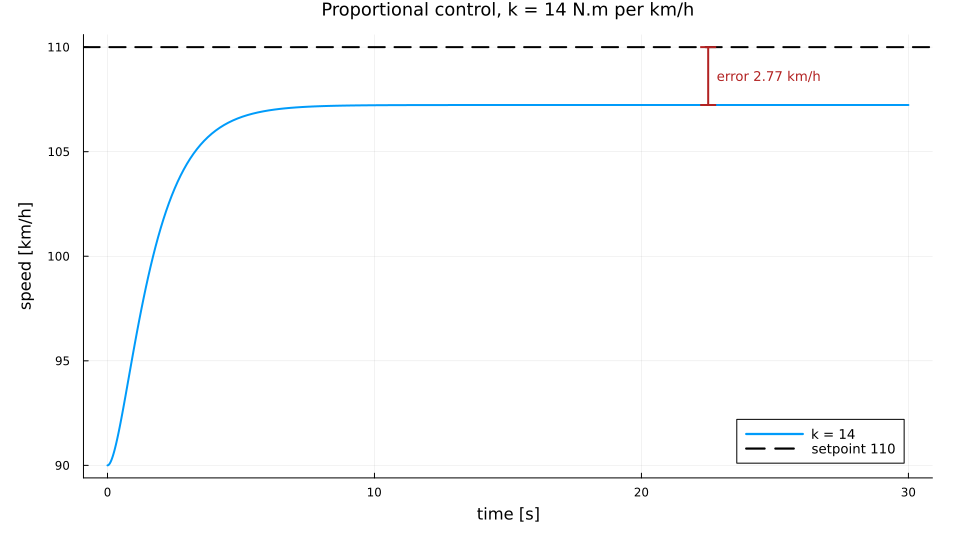

In [3]:
Scenarios = VehicleSystemsComponents.Lecture1

SPEED = "loop.plant.v_kmh"      # the plant's km/h output, inside the loop harness
COMMAND = "loop.controller.y"   # torque asked of the engine
SETPOINT = 110.0                # km/h
UNLIMITED = 1.0e6               # N.m — the torque ceiling, lifted out of the way

# `T_max` is the engine's physical ceiling and `y_max` the controller's own output clamp.
# Both are lifted: clamping either one would put a saturation nonlinearity in a notebook whose
# whole subject is the linear steady state.
single = Scenarios.CruiseLoopTransient(
    k = 14.0, T_max = UNLIMITED, y_max = UNLIMITED, stop = 30.0)

println("settled speed        ", round(signal(single, SPEED)[2][end], digits = 3), " km/h")
println("steady-state error   ", round(steady_state_error(single, SETPOINT; sig = SPEED), digits = 4), " km/h")
println("peak torque command  ", round(maximum(signal(single, COMMAND)[2]), digits = 1), " N.m")

plt = plot_speed(single; sig = SPEED, setpoint = SETPOINT, label = "k = 14",
                 title = "Proportional control, k = 14 N.m per km/h")
bracket_error!(plt, single; setpoint = SETPOINT, sig = SPEED)
save_figure(plt, "03-single-gain")
plt

Three things to read off that plot, in order.

**It works.** The car was holding 90 km/h, it was asked for 110, and it went and got most of the
way there in about five seconds. The open-loop car in notebook 01 had a time constant of about
a minute; this one is done in single-figure seconds. Feedback has not merely operated the
system, it has changed the system's dynamics, and a factor of twenty in the speed of response
is the most direct evidence of that in the whole lecture.

**It stops short.** The settled speed is 107.23 km/h against a setpoint of 110, an error of
2.77 km/h that does not shrink however long the simulation runs. Section 5 is about why.

**The error is a property of the loop, not of the run.** Restart it, wait longer, run it
backwards from 130 km/h — it settles 2.77 km/h below the setpoint every time, because that
number is the solution of an equilibrium condition rather than the residue of a transient.

`k = 14` is the gentlest gain in the family below, and it is deliberately the one this section
uses: it is the only one whose response settles without overshooting, so the error is readable
straight off the trace with nothing else happening on the plot to argue about.

## 3. Raising the gain

If a bigger gain commands more torque for the same error, a bigger gain should settle closer.
Four gains spanning two decades — 14, 56, 220 and 890 N.m per km/h — on the same step.

The model is compiled once and each point re-solves that same compiled problem with `k`
replaced, which is what `sweep` is for: recompiling per point would cost far more than solving
does.

  k        settled error      overshoot      peak command
  14       2.7686            0.0 %          280.0 N.m
  56       0.7101            39.0 %         1120.0 N.m
  220      -0.0875           259.8 %        4400.0 N.m
  890      -9.5018           1028.3 %       17800.0 N.m


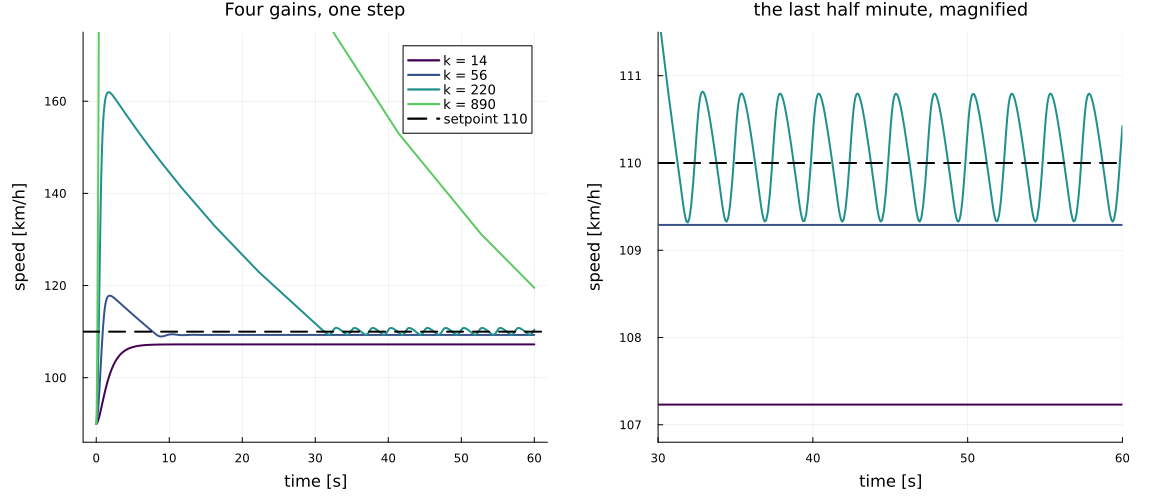

In [4]:
GAINS = [14.0, 56.0, 220.0, 890.0]

# Twice the window the single run needed. The two lower gains are long settled by 30 s, but
# whether the upper two settle at all is the question this cell exists to answer, and that
# takes watching them for a while.
family = sweep(
    Scenarios.CruiseLoopTransient(k = 14.0, T_max = UNLIMITED, y_max = UNLIMITED, stop = 60.0),
    "k", GAINS)

println("  k        settled error      overshoot      peak command")
for (k, sol) in family
    println("  ", rpad(Int(k), 7),
            "  ", rpad(round(steady_state_error(sol, SETPOINT; sig = SPEED), digits = 4), 16),
            "  ", rpad(string(round(overshoot(sol, SETPOINT; sig = SPEED), digits = 1), " %"), 13),
            "  ", round(maximum(signal(sol, COMMAND)[2]), digits = 0), " N.m")
end

whole = plot_sweep(family; sig = SPEED, setpoint = SETPOINT, name = "k",
                   title = "Four gains, one step", ylims = (86, 175), legend = :topright)
settled = plot_sweep(family; sig = SPEED, setpoint = SETPOINT, name = "k", legend = false,
                     title = "the last half minute, magnified",
                     xlims = (30.0, 60.0), ylims = (106.8, 111.5))
gain_family = plot(whole, settled; layout = (1, 2), size = (1150, 500))
save_figure(gain_family, "03-gain-family")
gain_family

The left panel is not the plot section 3 went looking for, and the right panel is the reason to
keep both.

**The two lower gains do what was predicted.** `k = 14` settles 2.77 km/h short and `k = 56`
settles 0.71 km/h short, so a four-fold gain shrank the error by very nearly four. That is the
result this section was after, and the right-hand panel is where it is legible.

**The two upper gains never settle at all.** At `k = 220` the car overshoots to 162 km/h and is
still swinging half a minute later; at `k = 890` it reaches 316 km/h and leaves the top of the
frame entirely. Their "steady-state error" is not small — it does not exist, because there is no
steady state to take it from. The printed numbers for those two rows are the average over the
last tenth of a run that is still moving, and they should be read as nothing more than that.

This is a real limit and not a numerical accident. `docs/HANDOVER.md` records the ultimate gain
of this plant at the shipping transport delay as **`Ku = 115` N.m per km/h** — the gain at which
proportional feedback alone drives the loop into sustained oscillation. Both upper gains are
above it, `k = 890` by a factor of nearly eight. What they show is not a badly tuned loop, it is
an unstable one, and notebook 08 goes back to that boundary deliberately and tunes a controller
from it.

So the gain family answers section 3's question and immediately poses another. Yes, more gain
means less error. And there is a ceiling on how much gain this car will take, which no amount of
wanting a smaller error will move.

## 4. Error against gain

The settled error is not a mystery once the equilibrium is written down. At steady state the car
is holding some speed $v_\infty$, the road is flat, and the force balance from notebook 01 says
the torque needed to hold that speed is

$$
T_{cruise}(v) \;=\; \left(\tfrac{1}{2}\rho C_{d}A\,v^{2} + f_{r}mg\right)\frac{r}{i}
$$

The controller is producing that torque, and the only thing it has to produce it from is the
error. So the settled error is whatever solves

$$
k \cdot e \;=\; T_{cruise}(v_{set} - e)
$$

one equation in one unknown, with no reference to the simulation at all. Solving it for a range
of `k` gives the curve below; the simulated runs are dropped on top of it.

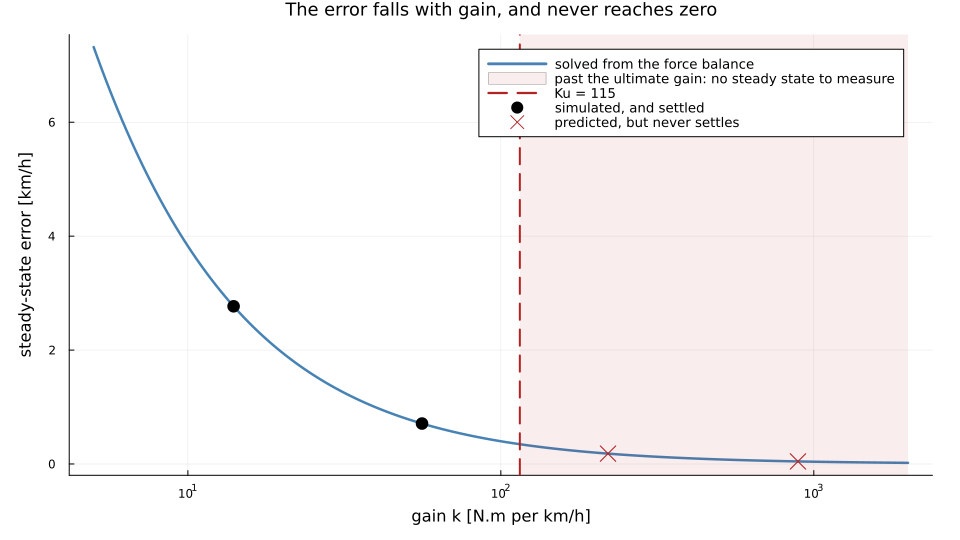

In [5]:
c_drag = 0.5 * CAR.rho * CAR.CdA                            # N per (m/s)^2
F_roll = CAR.f_r * CAR.m * CAR.g                            # N, flat road
cruise_torque(kmh) = (c_drag * (kmh / 3.6)^2 + F_roll) * CAR.r / CAR.i

# Fixed-point iteration on e = T_cruise(v_set - e)/k. The map is a shallow contraction for any
# gain worth using, so twenty passes is far more than convergence needs.
function settled_error(k; v_set = SETPOINT)
    e = 0.0
    for _ in 1:20
        e = cruise_torque(v_set - e) / k
    end
    return e
end

K_ULTIMATE = 115.0      # N.m per km/h, from docs/HANDOVER.md
ks = exp10.(range(log10(5), log10(2000); length = 200))

plt = plot(ks, settled_error.(ks);
    xscale = :log10, lw = 2.5, color = :steelblue, label = "solved from the force balance",
    xlabel = "gain k [N.m per km/h]", ylabel = "steady-state error [km/h]",
    title = "The error falls with gain, and never reaches zero")
vspan!(plt, [K_ULTIMATE, last(ks)]; color = :firebrick, alpha = 0.08,
       label = "past the ultimate gain: no steady state to measure")
vline!(plt, [K_ULTIMATE]; ls = :dash, lw = 2, color = :firebrick, label = "Ku = 115")

stable = [k for k in GAINS if k < K_ULTIMATE]
scatter!(plt, stable, [steady_state_error(sol, SETPOINT; sig = SPEED)
                       for (k, sol) in family if k < K_ULTIMATE];
         ms = 7, color = :black, label = "simulated, and settled")
scatter!(plt, [k for k in GAINS if k > K_ULTIMATE], settled_error.([k for k in GAINS if k > K_ULTIMATE]);
         ms = 8, marker = :xcross, color = :firebrick, label = "predicted, but never settles")
save_figure(plt, "03-error-vs-gain")
plt

The two simulated points that settled sit on the predicted curve, which is the useful check: the
arithmetic and the model agree, so the curve can be trusted where no simulation is possible.

And the curve's shape is the point. It is a hyperbola — halve the error by doubling the gain,
forever. It approaches zero and it reaches zero nowhere. The shaded region is the part of it
this car cannot be driven into, so even the asymptote is academic: the smallest error
proportional control can actually deliver here is about 0.35 km/h, at a gain just under the one
that makes the loop oscillate.

## 5. Why the error cannot be zero

The equation in section 4 is the whole explanation, and it is worth reading out loud rather than
solving.

**At equilibrium the car needs a non-zero torque just to hold its speed.** Drag and rolling
resistance do not stop pulling on a car that has reached the speed you asked for. At 110 km/h
they take 40.12 N.m to balance, and that torque has to come from somewhere.

**A proportional controller can only make torque out of error.** It has no other input. `u = k·e`
and nothing else.

**Therefore the error cannot be zero.** If it were, the command would be zero, the car would
slow down, and it would not be at equilibrium after all. The loop settles exactly where the
error is big enough to buy the torque the car needs — no smaller, and not by choice.

This is the drone that hovers just below the height you asked for, with drag playing the part
that gravity played. It is the oven that stabilizes a few degrees cool. It is not a defect in
any of those controllers, and no amount of care in tuning `k` removes it, because it is not a
tuning problem. **The controller is structurally unable to produce a steady output from a zero
input.**

Worth noticing before moving on: the error depends on the load. Put 200 kg in the boot, or point
the car up a hill, and `T_cruise` rises, so the settled error rises with it at the same gain.
The offset is not even a fixed property of the controller — it moves with the world.

## What this bought us

Proportional control turned a car that took a minute to respond into one that takes a few
seconds, and it will hold a speed near the one it was asked for against whatever the road does.
It is most of a cruise controller. What it will not do is arrive, and section 5 says the reason
is structural: a controller whose output is proportional to its input cannot hold a steady
output at zero input.

Read that as a specification and it names its own fix. We need something in the loop that can
**hold a non-zero output while its input is zero** — something with a memory, which keeps
producing the 40.12 N.m after the error that first justified it has gone.

That is **notebook 04**, and the thing that remembers is an integrator. The pleasure of that
notebook is that nobody has to tell it 40.12 N.m; it works the number out for itself.